Step 1:
[[ 1.   0.5 -0.5  4. ]
 [ 0.   0.5  0.5  1. ]
 [ 0.   2.   1.   5. ]]

Step 2:
[[ 1.  0. -1.  3.]
 [ 0.  1.  1.  2.]
 [ 0.  0. -1.  1.]]

Step 3:
[[ 1.  0.  0.  2.]
 [ 0.  1.  0.  3.]
 [-0. -0.  1. -1.]]

Solution: x = 2.00, y = 3.00, z = -1.00


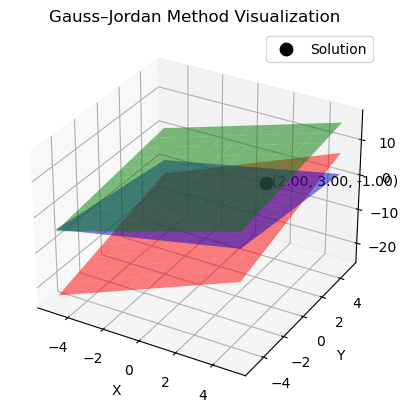

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Gauss–Jordan Method (RREF)
# -----------------------------
def gauss_jordan_method(A, b, verbose=False):
    aug = np.hstack((A.astype(float), b.reshape(-1, 1).astype(float)))  # Augmented matrix
    rows, cols = aug.shape

    for i in range(rows):
        # Make pivot = 1
        aug[i] = aug[i] / aug[i, i]

        # Make other entries in column i = 0
        for j in range(rows):
            if i != j:
                aug[j] = aug[j] - aug[j, i] * aug[i]

        if verbose:
            print(f"Step {i+1}:\n{aug}\n")

    # The last column is the solution
    return aug[:, -1]

# -----------------------------
# Example System
# -----------------------------
A = np.array([[2, 1, -1],
              [-3, -1, 2],
              [-2, 1, 2]], dtype=float)
b = np.array([8, -11, -3], dtype=float)

solution = gauss_jordan_method(A, b, verbose=True)
x, y, z = solution
print(f"Solution: x = {x:.2f}, y = {y:.2f}, z = {z:.2f}")

# -----------------------------
# Visualization
# -----------------------------
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create grid
xx, yy = np.meshgrid(range(-5, 6), range(-5, 6))

# Plane equations
z1 = 2*xx + yy - 8
z2 = (3*xx + yy + 11) / 2
z3 = (2*xx - yy - 3) / 2

# Plot planes
ax.plot_surface(xx, yy, z1, alpha=0.5, color='red')
ax.plot_surface(xx, yy, z2, alpha=0.5, color='green')
ax.plot_surface(xx, yy, z3, alpha=0.5, color='blue')

# Plot solution
ax.scatter(x, y, z, color='black', s=80, label='Solution')
ax.text(x+0.3, y, z, f"({x:.2f}, {y:.2f}, {z:.2f})", color='black')

# Labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Gauss–Jordan Method Visualization')
ax.legend()

plt.show()
